# 04. Какие новые признаки действительно помогают

После прошлого сравнения впереди CatBoost без User-Agent. Он видит 47 признаков: сколько было действий, насколько они разнообразны, каковы паузы между ними. Попробуем описать ещё и ход сессии. Есть ли длинные серии действий? Что человек делает после поиска или просмотра объявления? Возвращается ли к одним и тем же товарам?

Новые признаки будем добавлять группами. Сравним их на тех же трёх отрезках, а потом уберём по одному признаку из лучшей группы. Так проще понять, за счёт чего меняется результат. Ноутбук можно открыть из корня проекта или из папки `notebooks/`. Код расчёта признаков лежит в `utils/features.py`, метрика в `utils/metric.py`. Python 3.12, версии библиотек есть в `requirements.txt`

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
from utils.features import build_features
from utils.metric import precision_at_recall

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})

root = Path("data")
train = pd.read_csv(root / "train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(root / "test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(root / "events.csv.gz", parse_dates=["event_ts"])
print(f"Python {sys.version.split()[0]} | train: {len(train):,} кук | test: {len(test):,} кук")

Python 3.12.10 | train: 11,091 кук | test: 4,909 кук


## Сначала отсекаем лишние события

У каждой куки своё окно: начало включаем, конец нет. Все агрегаты ниже считаются только по событиям внутри этого окна. Само значение `target` функция признаков не получает. Старый набор в ней повторён из ноутбука 03, поэтому новый CatBoost можно сравнивать с прежним без смены исходной точки

In [2]:
features, groups, n_inside = build_features(train, test, events)
X_train = features.iloc[:len(train)].reset_index(drop=True)
X_test = features.iloc[len(train):].reset_index(drop=True)
y = train.target.to_numpy()
ua_columns = {"headless_ua", "automation_ua", "ua_count"}
base_columns = [column for column in groups["base"] if column not in ua_columns]

assert X_train.cookie_id.equals(train.cookie_id)
assert X_test.cookie_id.equals(test.cookie_id)
assert len(set(sum(groups.values(), []))) == len(sum(groups.values(), []))
numeric_features = features[sum(groups.values(), [])].to_numpy(dtype=float)
assert np.isfinite(numeric_features[~np.isnan(numeric_features)]).all()
print(f"Событий внутри окон: {n_inside:,} из {len(events):,}")
print("Признаков:", {name: len(columns) for name, columns in groups.items()})
print("Базовых без User-Agent:", len(base_columns))

Событий внутри окон: 288,126 из 328,905
Признаков: {'base': 50, 'rhythm': 11, 'routes': 7, 'breadth': 9}
Базовых без User-Agent: 47


## Три идеи для новых признаков

- **Ритм**: активные минуты, самый плотный пятиминутный отрезок, длинные паузы и серии действий с промежутками до 30 секунд.
- **Маршруты**: что следует сразу после поиска или просмотра объявления, повторяется ли тип действия и как часто контакт происходит вскоре после просмотра.
- **Разнообразие**: повторы объявлений, концентрация на одном товаре, разброс категорий, локаций и запросов.

Названия групп здесь нужны для эксперимента. Они не говорят, что поведение само по себе плохое: человек тоже может быстро открыть много объявлений

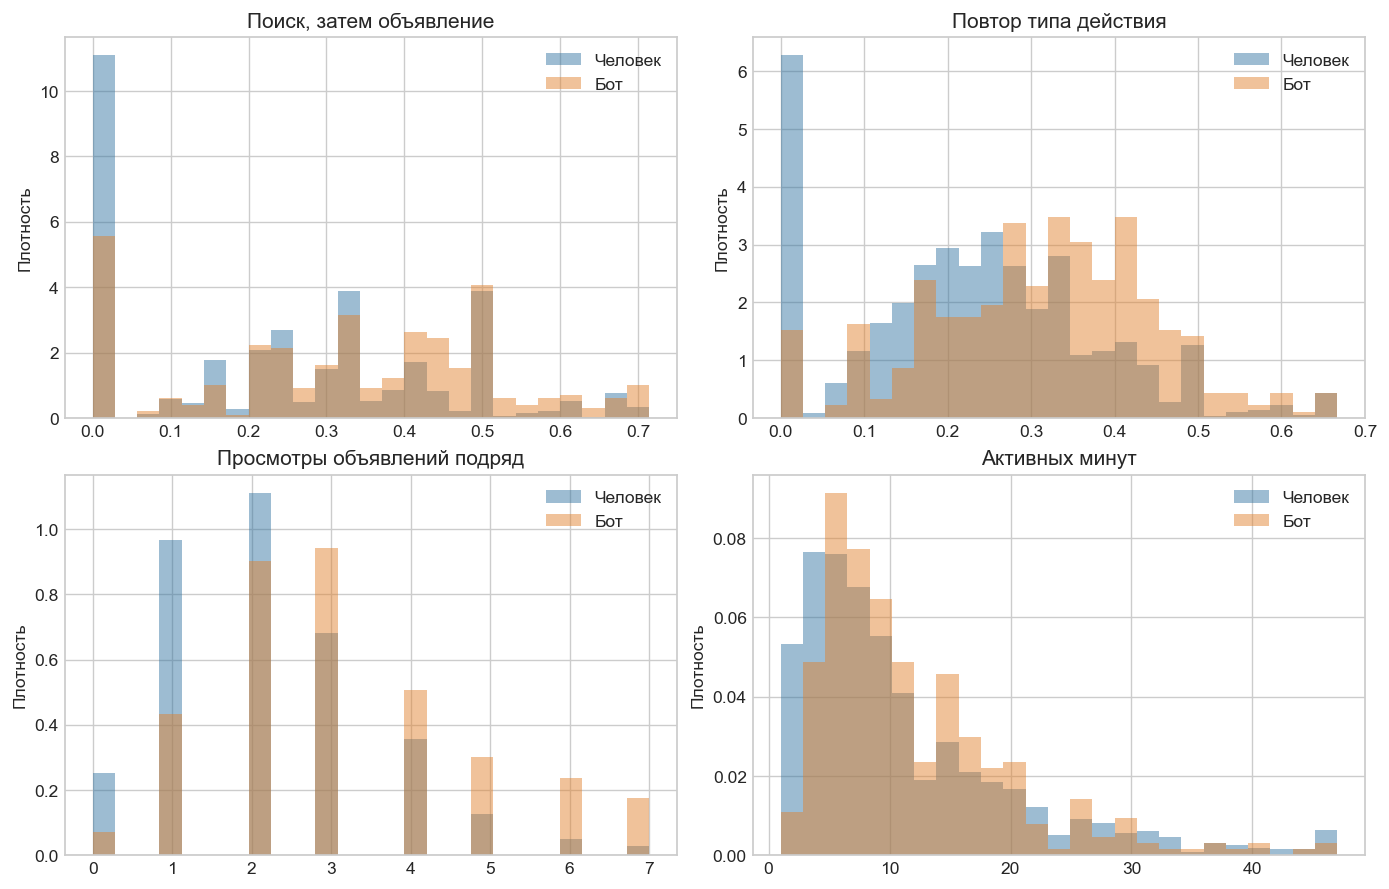

In [3]:
# Для рисунков берём только ранние дни train, до первой проверки.
early = X_train.window_start_ts.lt("2026-04-11").to_numpy()
examples = [
    ("search_to_item_rate", "Поиск, затем объявление"),
    ("same_event_next_share", "Повтор типа действия"),
    ("max_item_view_run", "Просмотры объявлений подряд"),
    ("active_minutes", "Активных минут"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
for ax, (column, title) in zip(axes.flat, examples):
    cap = X_train.loc[early, column].quantile(.99)
    for label, color in [(0, "#3274A1"), (1, "#E1812C")]:
        values = X_train.loc[early & (y == label), column].dropna().clip(upper=cap)
        ax.hist(values, bins=25, density=True, alpha=.48, color=color,
                label="Бот" if label else "Человек")
    ax.set(title=title, ylabel="Плотность")
    ax.legend()
plt.show()

На этих рисунках классы перекрываются. Отдельным правилом вроде «много просмотров подряд = бот» тут не обойтись. Проверим, помогает ли сочетание признаков модели

## Проверяем по времени

Те же три проверки, что в ноутбуке 03: модель обучается только на днях до проверочного отрезка. Ничего не перемешиваем. Главная метрика: Precision при Recall не ниже 70%. PR-AUC запишем для диагностики, но решение будем принимать по основной метрике

In [4]:
folds = [
    ("11–13 апреля", "2026-04-11", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20"),
]
configs = {
    "base": base_columns,
    "rhythm": base_columns + groups["rhythm"],
    "routes": base_columns + groups["routes"],
    "breadth": base_columns + groups["breadth"],
    "routes_rhythm": base_columns + groups["routes"] + groups["rhythm"],
    "all": base_columns + groups["rhythm"] + groups["routes"] + groups["breadth"],
}
labels = {
    "base": "Старый CatBoost", "rhythm": "+ ритм", "routes": "+ маршруты",
    "breadth": "+ разнообразие", "routes_rhythm": "+ маршруты и ритм",
    "all": "+ все новые",
}

def make_model():
    # Параметры те же, что в ноутбуке 03. Меняем только набор признаков.
    return CatBoostClassifier(
        iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
        loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
        thread_count=4, allow_writing_files=False,
    )

rows = []
validation_parts = []
for name, columns in configs.items():
    for fold_name, start, end in folds:
        fit = X_train.window_start_ts.lt(start).to_numpy()
        valid = (X_train.window_start_ts.ge(start) & X_train.window_start_ts.lt(end)).to_numpy()
        assert X_train.loc[fit, "window_start_ts"].max() < X_train.loc[valid, "window_start_ts"].min()
        model = make_model()
        model.fit(X_train.loc[fit, columns], y[fit])
        score = model.predict_proba(X_train.loc[valid, columns])[:, 1]
        rows.append({
            "model": name, "fold": fold_name,
            "p_at_r70": precision_at_recall(y[valid], score),
            "pr_auc": average_precision_score(y[valid], score),
        })
        validation_parts.append(pd.DataFrame({
            "cookie_id": X_train.loc[valid, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid], "model": name, "score": score,
        }))
    print(f"Готово: {labels[name]}")
results = pd.DataFrame(rows)
validation_long = pd.concat(validation_parts, ignore_index=True)

Готово: Старый CatBoost


Готово: + ритм


Готово: + маршруты


Готово: + разнообразие


Готово: + маршруты и ритм


Готово: + все новые


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
Старый CatBoost,0.461,0.544,0.560,0.521
+ ритм,0.443,0.552,0.574,0.523
+ маршруты,0.484,0.509,0.596,0.530
+ разнообразие,0.399,0.509,0.514,0.474
+ маршруты и ритм,0.470,0.500,0.596,0.522
+ все новые,0.488,0.495,0.563,0.515


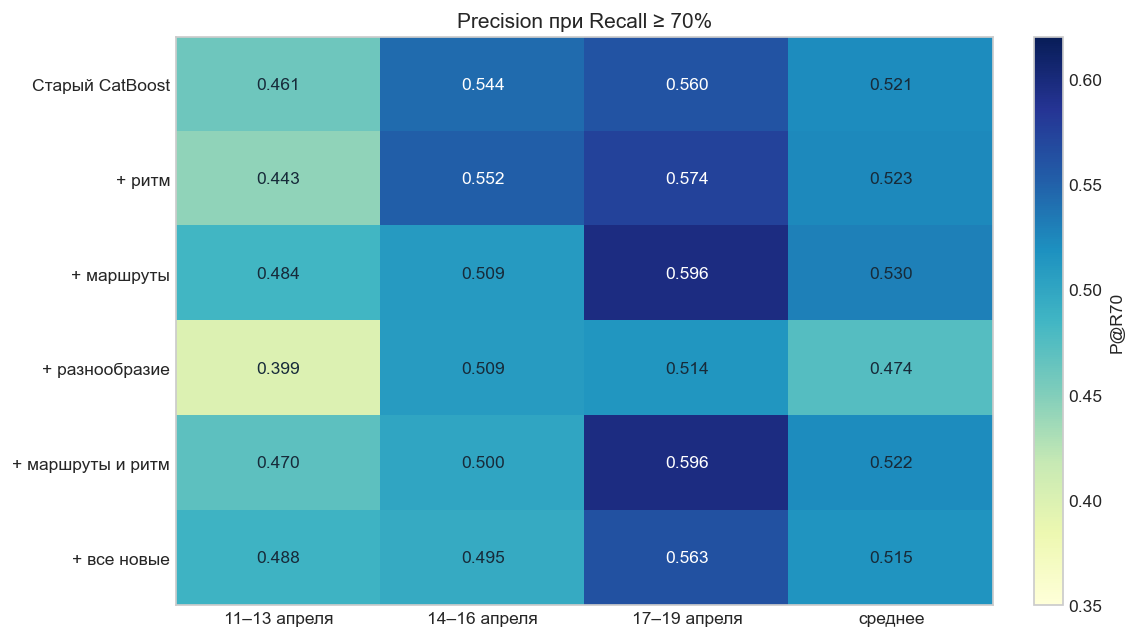

Старый CatBoost воспроизведён: разница в score меньше 1e-8


In [5]:
summary = results.pivot(index="model", columns="fold", values="p_at_r70")
summary = summary[[name for name, _, _ in folds]]
summary["среднее"] = summary.mean(axis=1)
summary = summary.loc[list(configs)]
summary.index = summary.index.map(labels)
display(summary.round(3))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
values = summary.to_numpy()
heat = ax.imshow(values, cmap="YlGnBu", vmin=.35, vmax=.62, aspect="auto")
ax.grid(False)
ax.set(xticks=range(len(summary.columns)), yticks=range(len(summary)),
       xticklabels=summary.columns, yticklabels=summary.index,
       title="Precision при Recall ≥ 70%")
for row in range(values.shape[0]):
    for col in range(values.shape[1]):
        ax.text(col, row, f"{values[row, col]:.3f}", ha="center", va="center",
                color="white" if values[row, col] > .53 else "#172b3a")
fig.colorbar(heat, ax=ax, label="P@R70")
plt.show()

# Проверяем, что стартовая точка действительно та же, что в прошлом ноутбуке.
old = pd.read_csv("output/model_validation_scores.csv")
old_score = old.set_index("cookie_id").loc[
    validation_long.loc[validation_long.model.eq("base"), "cookie_id"],
    "catboost_no_ua",
].to_numpy()
new_score = validation_long.loc[validation_long.model.eq("base"), "score"].to_numpy()
assert np.max(np.abs(old_score - new_score)) < 1e-8
print("Старый CatBoost воспроизведён: разница в score меньше 1e-8")

Лучше всех новых групп выглядят маршруты: среднее P@R70 выросло с 0,521 до 0,530, на последнем отрезке с 0,560 до 0,596. Разнообразие просадило качество, а добавление ритма к маршрутам не дало нового выигрыша. При этом на среднем отрезке сами маршруты уступили старой модели. Вывод пока скромный: кандидата для финального сравнения нашли, гарантии улучшения на test нет

## Может, в маршрутах хватает пары признаков?

Уберём каждый из семи признаков по очереди и снова прогоним три отрезка. Это дороже, чем посмотреть на встроенную важность CatBoost, зато отвечает на более прямой вопрос: как меняется качество без признака? Числа всё равно могут гулять из-за того, что основная метрика чувствительна к порядку кук возле порога

In [6]:
ablation_rows = []
for removed in groups["routes"]:
    columns = base_columns + [column for column in groups["routes"] if column != removed]
    for fold_name, start, end in folds:
        fit = X_train.window_start_ts.lt(start).to_numpy()
        valid = (X_train.window_start_ts.ge(start) & X_train.window_start_ts.lt(end)).to_numpy()
        model = make_model()
        model.fit(X_train.loc[fit, columns], y[fit])
        score = model.predict_proba(X_train.loc[valid, columns])[:, 1]
        ablation_rows.append({
            "убранный признак": removed, "отрезок": fold_name,
            "p_at_r70": precision_at_recall(y[valid], score),
        })
ablation = pd.DataFrame(ablation_rows).pivot(
    index="убранный признак", columns="отрезок", values="p_at_r70"
)
ablation = ablation[[name for name, _, _ in folds]]
ablation["среднее"] = ablation.mean(axis=1)
ablation["разница со всеми маршрутами"] = ablation["среднее"] - summary.loc["+ маршруты", "среднее"]
display(ablation.sort_values("среднее", ascending=False).round(3))

отрезок,11–13 апреля,14–16 апреля,17–19 апреля,среднее,разница со всеми маршрутами
убранный признак,,,,,
item_to_seller_rate,0.497,0.511,0.574,0.527,-0.002
contact_after_view_5min_share,0.470,0.511,0.599,0.527,-0.003
item_to_contact_rate,0.472,0.557,0.546,0.525,-0.005
max_item_view_run,0.476,0.525,0.563,0.521,-0.009
search_to_item_rate,0.483,0.529,0.552,0.521,-0.009
item_to_photo_rate,0.465,0.489,0.605,0.520,-0.010
same_event_next_share,0.456,0.533,0.565,0.518,-0.012


Ни одно удаление не улучшило среднее относительно полного набора маршрутов. Разницы небольшие, поэтому не будем объявлять каждый из семи признаков незаменимым. Для следующего этапа оставим всю группу, а ритм и разнообразие пока не добавляем. L1-регрессия отбирала бы признаки для линейной модели, а здесь важнее поведение бустинга на будущих днях

## Сохраняем оценки кандидатов

В заключительном ноутбуке пригодятся предсказания на проверочных отрезках и test. Для test каждую версию учим заново на всём train. Это не финальный `submission.csv`: решать, брать ли новый CatBoost или смешивать его со старым, будем после сравнения ошибок

In [7]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
validation_path = output_dir / "feature_validation_scores.csv"
test_path = output_dir / "feature_test_scores.csv"

validation_wide = validation_long.pivot(
    index=["cookie_id", "fold", "target"], columns="model", values="score"
).reset_index()
validation_wide.columns.name = None
validation_wide.to_csv(validation_path, index=False, float_format="%.10f")

test_candidates = pd.DataFrame({"cookie_id": test.cookie_id})
full_models = {}
for name, columns in configs.items():
    model = make_model()
    model.fit(X_train[columns], y)
    full_models[name] = model
    test_candidates[name] = model.predict_proba(X_test[columns])[:, 1]
test_candidates.to_csv(test_path, index=False, float_format="%.10f")

assert len(validation_wide) == len(old) and validation_wide.cookie_id.is_unique
assert validation_wide[list(configs)].notna().all().all()
assert test_candidates.cookie_id.equals(test.cookie_id)
assert test_candidates.drop(columns="cookie_id").apply(lambda s: s.between(0, 1).all()).all()
assert pd.read_csv(test_path).cookie_id.equals(test.cookie_id)
print(f"Сохранены {validation_path} и {test_path}")
print("Test:", len(test_candidates), "кук")

Сохранены output/feature_validation_scores.csv и output/feature_test_scores.csv
Test: 4909 кук


Встроенная важность признаков покажет, какие столбцы CatBoost чаще использовал для разделения. Это подсказка для проверки, а не доказательство, что признак вызывает ботовость. Особенно осторожно читаем близкие друг к другу счётчики

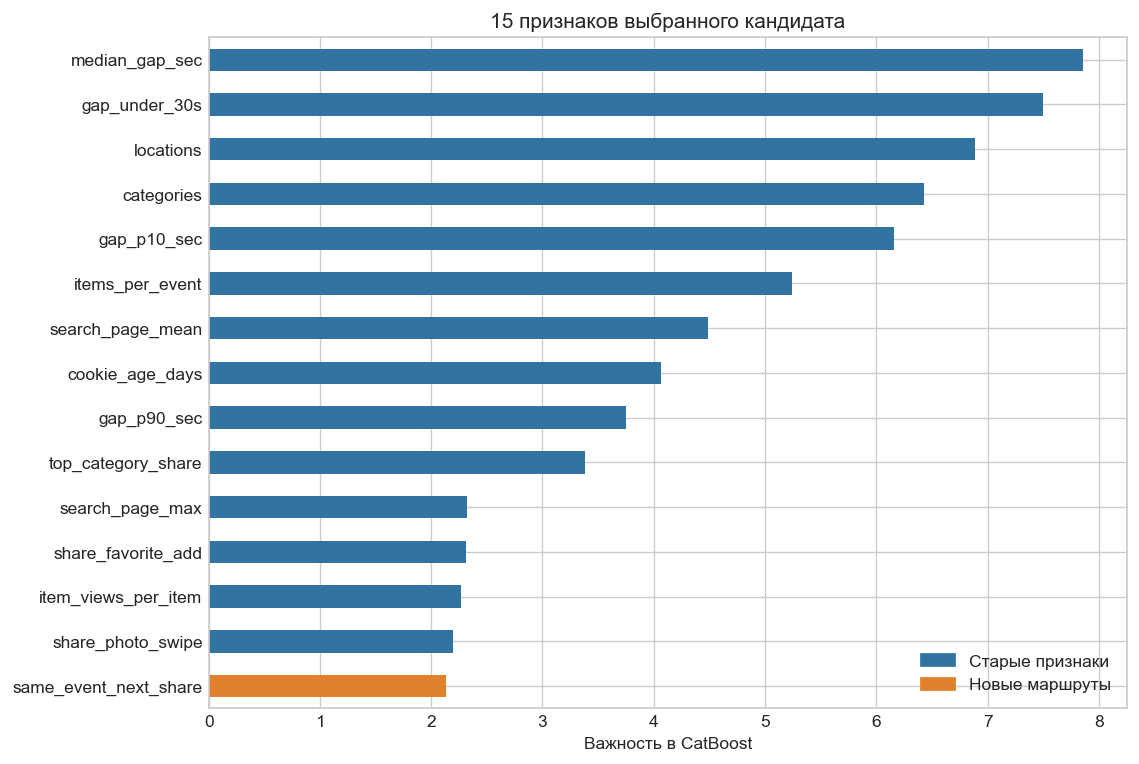

,важность маршрутов
same_event_next_share,2.14
item_to_photo_rate,1.15
item_to_seller_rate,1.08
search_to_item_rate,0.97
item_to_contact_rate,0.84
contact_after_view_5min_share,0.44
max_item_view_run,0.26


In [8]:
selected_columns = configs["routes"]
importance = pd.Series(
    full_models["routes"].get_feature_importance(), index=selected_columns
).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")
sorted_importance = importance.sort_values()
colors = ["#E1812C" if column in groups["routes"] else "#3274A1"
          for column in sorted_importance.index]
sorted_importance.plot.barh(ax=ax, color=colors)
ax.set(xlabel="Важность в CatBoost", title="15 признаков выбранного кандидата")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#3274A1", label="Старые признаки"),
                   Patch(color="#E1812C", label="Новые маршруты")])
plt.show()
route_importance = pd.Series(
    full_models["routes"].get_feature_importance(), index=selected_columns
).loc[groups["routes"]].sort_values(ascending=False)
display(route_importance.rename("важность маршрутов").round(2).to_frame())

## Что берём дальше

Основной новый кандидат: CatBoost с семью признаками маршрута. Его средняя точность при нужной полноте 0,530 против 0,521 у старой версии без User-Agent. На последних днях разница заметнее, но средний отрезок напоминает, что выигрыш нестабилен. Все признаки вычисляются из разрешённого суточного окна. Оценки всех проверенных групп сохранили в `output/feature_validation_scores.csv` и `output/feature_test_scores.csv`. В ноутбуке 05 разберём признаки по объявлениям, а затем сравним отдельные модели и их смеси. Меток скрытого теста у нас нет